In [ ]:
!pip install kaggle --quiet
import sys
import numpy as np
import os, json
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
with open("/content/drive/MyDrive/MatApl/Ayudantías/26-1 Ayudantias/Redes Complejas/Clases/kaggle_key.json", "r") as f:
    cred = json.load(f)

os.environ["KAGGLE_USERNAME"] = cred["username"]
os.environ["KAGGLE_KEY"] = cred["key"]

In [ ]:
!kaggle datasets download -d gregorut/videogamesales

Dataset URL: https://www.kaggle.com/datasets/gregorut/videogamesales
License(s): unknown
videogamesales.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
data = pd.read_csv("/content/videogamesales.zip")

# EDA

## 1. Conociendo el Dataset

In [ ]:
display(data)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [ ]:
#Tabla hecha con IA para ejemplo con Merge
plataformas = pd.read_excel("/content/drive/MyDrive/MatApl/Ayudantías/Ayudantías27-1/RedesMulticapa/Clases/Auxiliares/plataformas_info.xlsx",
                            sheet_name="Plataformas")

data.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [ ]:
data.tail()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [ ]:
data.shape
#¿cuántos juegos y cuántas variables (columnas) tenemos en total?
print(f"El dataset tiene {data.shape[0]} juegos registrados y {data.shape[1]} columnas.")

El dataset tiene 16598 juegos registrados y 11 columnas.


In [ ]:
data.info()
#¿qué tipo de dato tiene cada columna, y en cuáles hay valores
#faltantes?
#'Year' y 'Publisher' tienen mas registros nulos
#'Year' está como float (por los NaN) en # vez de int.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
print(data.describe(),'\n')
#¿cómo se distribuyen las ventas?
#media, mínimo, máximo, percentiles de columnas numéricas.

#Se nota que la media de Global_Sales está muy por encima de la mediana,
#indicando una "cola larga": pocos juegos (como Wii Sports) empujan
#el promedio hacia arriba mientras la mayoría vende poco.
print("Media de ventas globales:", round(data["Global_Sales"].mean(), 3), "millones")
print("Mediana de ventas globales:", round(data["Global_Sales"].median(), 3), "millones")

               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000   
mean    8300.605254   2006.406443      0.264667      0.146652      0.077782   
std     4791.853933      5.828981      0.816683      0.505351      0.309291   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4151.250000   2003.000000      0.000000      0.000000      0.000000   
50%     8300.500000   2007.000000      0.080000      0.020000      0.000000   
75%    12449.750000   2010.000000      0.240000      0.110000      0.040000   
max    16600.000000   2020.000000     41.490000     29.020000     10.220000   

        Other_Sales  Global_Sales  
count  16598.000000  16598.000000  
mean       0.048063      0.537441  
std        0.188588      1.555028  
min        0.000000      0.010000  
25%        0.000000      0.060000  
50%        0.010000      0.170000  
75%        0.040000      0.470000  


## 2. Consultas y Extracción de información

In [ ]:
#df['columna']
#Pregunta: ¿cuáles son los géneros que existen en el dataset y cuántos juegos hay de cada uno?
data["Genre"].value_counts()

,count
Genre,
Action,3316
Sports,2346
Misc,1739
Role-Playing,1488
Shooter,1310
Adventure,1286
Racing,1249
Platform,886
Simulation,867


In [ ]:
#df.loc[] (filtra por condición Y elegir columnas por nombre al mismo tiempo)
#Pregunta: ¿qué juegos de PS4 vendieron más de 400,000 copias en Japón?

data.loc[
    (data["Platform"] == "PS4") & (data["JP_Sales"] > 0.4),
    ["Name", "Publisher", "JP_Sales", "Global_Sales"]
]

,Name,Publisher,JP_Sales,Global_Sales
395,Metal Gear Solid V: The Phantom Pain,Konami Digital Entertainment,0.48,3.38
1087,Knack,Sony Computer Entertainment Europe,0.42,1.67


In [ ]:
#Pregunta: ¿cuáles son los juegos de Nintendo publicados antes del año 2000?
data.loc[
    (data["Publisher"] == "Nintendo") & (data["Year"] < 2000),
    ["Name", "Platform", "Year", "Global_Sales"]
]

,Name,Platform,Year,Global_Sales
1,Super Mario Bros.,NES,1985.0,40.24
4,Pokemon Red/Pokemon Blue,GB,1996.0,31.37
5,Tetris,GB,1989.0,30.26
9,Duck Hunt,NES,1984.0,28.31
12,Pokemon Gold/Pokemon Silver,GB,1999.0,23.10
...,...,...,...,...
8426,Street Fighter Alpha 2,SNES,1996.0,0.17
8449,Itoi Shigesato no Bass Tsuri No. 1,SNES,1997.0,0.17
8875,Tetris Attack,SNES,1995.0,0.15
9461,Illusion of Gaia,SNES,1993.0,0.13


In [ ]:
#df.iloc[] (igual que loc pero por índice de filas y columnas)
#Pregunta: ¿cuáles son los 10 juegos con mayores ventas globales,
#mostrando solo nombre, plataforma y ventas?
#Como el dataset ya está ordenado por Rank, las primeras 10 filas son el top 10 mundial.
data.iloc[0:10,
         [1, 2, -1]]   #columnas: Name, Platform, Global_Sales

,Name,Platform,Global_Sales
0,Wii Sports,Wii,82.74
1,Super Mario Bros.,NES,40.24
2,Mario Kart Wii,Wii,35.82
3,Wii Sports Resort,Wii,33.00
4,Pokemon Red/Pokemon Blue,GB,31.37
5,Tetris,GB,30.26
6,New Super Mario Bros.,DS,30.01
7,Wii Play,Wii,29.02
8,New Super Mario Bros. Wii,Wii,28.62
9,Duck Hunt,NES,28.31


In [ ]:
# df.iloc[] con "step"
#Pregunta: ya que el dataset está ordenado por ventas (de mayor a menor)
#¿cómo se ve la caída de ventas si tomamos una muestra cada 200 posiciones?

#iloc permite hacer slicing de step (inicio:fin:paso)
data.iloc[::200, [1, 2, 3, -1]]
#Comfirmamos el patrón de "cola larga: las ventas caen muy rápido
#apenas nos alejamos de los primeros puestos, y después el resto del
#ranking vende cantidades muy parecidas y bajas entre sí.

,Name,Platform,Year,Global_Sales
0,Wii Sports,Wii,2006.0,82.74
200,Super Mario Bros.,GB,1999.0,5.07
400,Rugrats: Search For Reptar,PS,1998.0,3.34
600,Madden NFL 08,PS2,2007.0,2.57
800,Tetris Worlds,PS2,2002.0,2.08
...,...,...,...,...
15600,Emergency 2012,DS,2010.0,0.02
15800,Pro Rally,GC,2002.0,0.02
16000,Smart Kid's Mega Game Mix,DS,2009.0,0.01
16200,Hyakka Yakou,PSV,2015.0,0.01


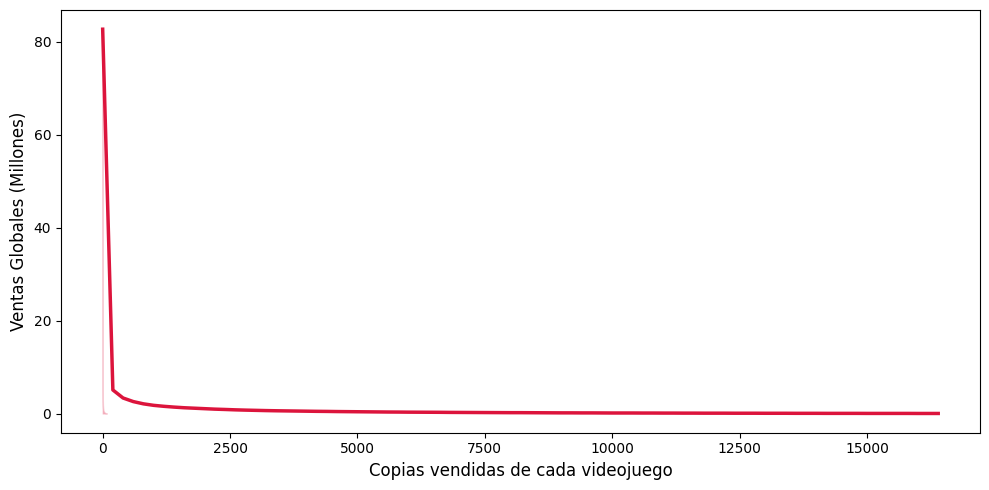

In [ ]:
subset = data.iloc[::200, [1, 2, 3, -1]]

plt.figure(figsize=(10, 5))
plt.plot(subset["Global_Sales"], color="crimson", linewidth=2.5, label="Unidades vendidas")
plt.fill_between(range(len(subset)), subset["Global_Sales"], color="crimson", alpha=0.2)

plt.xlabel("Copias vendidas de cada videojuego", fontsize=12)
plt.ylabel("Ventas Globales (Millones)", fontsize=12)

plt.tight_layout()
plt.show()

## 3. Modificación del Dataset


In [ ]:
#Explorar los nulos

display(data.isna().sum())
#¿cuántos valores faltan por columna?
#Vemos nulos en 'Year' y'Publisher'
print("% de nulos en Year:", round(data["Year"].isna().sum()/len(data),3))
print("Nulos en Publisher:", round(data["Publisher"].isna().sum()/len(data),3))

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,58
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


% de nulos en Year: 0.016
Nulos en Publisher: 0.003


In [ ]:
data[data["Year"].isna()]

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


¿Por qué FIFA Soccer 2004 tiene Nan en año? error al hacer webscrapping, pues en Europa se llama "FIFA Football 2004" y en EEUU "FIFA Soccer 2004", además, las fechas no fueron el mismo día, por lo que el webscrapper se "confundió".

 EEUU   11/04/03

 Japon  Cancelled

 UE     10/24/03

In [ ]:
#df.dropna() (Elimina registros con NaN, NaT o None)

#Pregunta: si tuviéramos que quedarnos SOLO con juegos que
#tienen año Y publisher conocidos, ¿cuántos registros perderíamos?
data_sin_nulos_criticos = data.dropna(subset=["Year", "Publisher"])
print(f"Filas originales: {len(data)} | Filas sin nulos en Year/Publisher: {len(data_sin_nulos_criticos)}")
print(f"Se pierden {len(data) - len(data_sin_nulos_criticos)} registros ({(1 - len(data_sin_nulos_criticos)/len(data)):.1%})")

Filas originales: 16598 | Filas sin nulos en Year/Publisher: 16291
Se pierden 307 registros (1.8%)


In [ ]:
#df.fillna() (Rellena los valores faltantes con el que seleccionemos)
data["Publisher"] = data["Publisher"].fillna("Unknown")
data["Publisher"].isna().sum()   #debería dar 0

np.int64(0)

In [ ]:
#df.astype() (cambiar el tipo de dato de una columna)

#¿cómo optimizamos memoria y dejamos más claro que 'Genre' y 'Platform' son
#variables categóricas y no texto libre?
data["Genre"] = data["Genre"].astype("category")
data["Platform"] = data["Platform"].astype("category")
data.dtypes[["Genre", "Platform"]]

,0
Genre,category
Platform,category


In [ ]:
# df.rename() (renombrar columnas)

data_renombrada = data.rename(columns={
    "Rank": "rango",
    "Name": "nombre",
    "Platform": "plataforma",
    "Year": "anio",
    "Genre": "genero",
    "Publisher": "publisher",
    "NA_Sales": "ventas_na",
    "EU_Sales": "ventas_eu",
    "JP_Sales": "ventas_jp",
    "Other_Sales": "ventas_otros",
    "Global_Sales": "ventas_globales",
})
data_renombrada.columns.tolist()

['rango',
 'nombre',
 'plataforma',
 'anio',
 'genero',
 'publisher',
 'ventas_na',
 'ventas_eu',
 'ventas_jp',
 'ventas_otros',
 'ventas_globales']

In [ ]:
data.columns.tolist()

['Rank',
 'Name',
 'Platform',
 'Year',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales']

In [ ]:
# df.drop() (Elimina una columna)

#'Rank' es redundante porque ya podemos ordenar 'ventas_globales', no aporta
#información nueva para el análisis
data = data.drop(columns=["Rank"])
data.columns.tolist()

['Name',
 'Platform',
 'Year',
 'Genre',
 'Publisher',
 'NA_Sales',
 'EU_Sales',
 'JP_Sales',
 'Other_Sales',
 'Global_Sales']

## 4. Agrupación y Agregación de Datos

In [ ]:
#df.groupby() + sum() (Agrupar datos para usar funciones de agregación)
#Pregunta: ¿qué género de videojuego generó más ventas globales acumuladas históricamente?
ventas_por_genero = data.groupby("Genre", observed=True)["Global_Sales"].sum().sort_values(ascending=False)
ventas_por_genero

,Global_Sales
Genre,
Action,1751.18
Sports,1330.93
Shooter,1037.37
Role-Playing,927.37
Platform,831.37
Misc,809.96
Racing,732.04
Fighting,448.91
Simulation,392.20


In [ ]:
#df.groupby() + mean()
#Pregunta: ¿qué género vende mas en PROMEDIO por título?
promedio_por_genero = data.groupby("Genre", observed=True)["Global_Sales"].mean().sort_values(ascending=False)
promedio_por_genero

,Global_Sales
Genre,
Platform,0.938341
Shooter,0.791885
Role-Playing,0.623233
Racing,0.586101
Sports,0.567319
Fighting,0.529375
Action,0.528100
Misc,0.465762
Simulation,0.452364


In [ ]:
#df.groupby() + count()
#Pregunta: ¿cuántos juegos publicó cada publisher?
juegos_por_publisher = data.groupby("Publisher", observed=True)["Name"].count().sort_values(ascending=False)
juegos_por_publisher.head(10)

,Name
Publisher,
Electronic Arts,1351
Activision,975
Namco Bandai Games,932
Ubisoft,921
Konami Digital Entertainment,832
THQ,715
Nintendo,703
Sony Computer Entertainment,683
Sega,639


In [ ]:
#df.groupby() con múltiples columnas + sum()

#¿cómo se reparten las ventas de cada plataforma entre las
#distintas regiones del mundo (Norteamérica, Europa, Japón)?
ventas_por_plataforma_region = data.groupby("Platform", observed=True)[
    ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
].sum()
ventas_por_plataforma_region.sort_values("NA_Sales", ascending=False).head(10)

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
Platform,,,,
X360,601.05,280.58,12.43,85.54
PS2,583.84,339.29,139.20,193.44
Wii,507.71,268.38,69.35,80.61
PS3,392.26,343.71,79.99,141.93
DS,390.71,194.65,175.57,60.53
PS,336.51,213.60,139.82,40.91
GBA,187.54,75.25,47.33,7.73
XB,186.69,60.95,1.38,8.72
N64,139.02,41.06,34.22,4.38


## 5. Consultas a Múltiples Tablas

In [ ]:
#2da tabla (Hecha con IA) tiene el fabricante y la generación de cada consola.
#La columna en común con 'data' es el nombre de la consola o "Platform".
plataformas.head()

,Platform,Fabricante,Generacion,Anio_Lanzamiento_Plataforma
0,Wii,Nintendo,7.0,2006.0
1,NES,Nintendo,3.0,1983.0
2,GB,Nintendo,4.0,1989.0
3,DS,Nintendo,7.0,2004.0
4,X360,Microsoft,7.0,2005.0


In [ ]:
#pd.merge() (permite unir 2 dataframes que compartan alguna columna)

#Pregunta: ¿cuánto vendió cada FABRICANTE en total, sumando todas sus plataformas?
data_con_fabricante = data.merge(
    plataformas[["Platform", "Fabricante"]],
    on="Platform",
    how="left",
    indicator=True #da la columna _merge
)

data_con_fabricante

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Fabricante,_merge
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,Nintendo,both
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,Nintendo,both
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,Nintendo,both
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,Nintendo,both
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,Nintendo,both
...,...,...,...,...,...,...,...,...,...,...,...,...
16593,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01,Nintendo,both
16594,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01,Nintendo,both
16595,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01,Sony,both
16596,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01,Nintendo,both


In [ ]:
#Chequeamos si algo quedó sin matchear
data_con_fabricante["_merge"].value_counts()

,count
_merge,
both,15848
left_only,750
right_only,0


In [ ]:
#¿qué plataformas quedaron sin fabricante asignado tras el left join?
data_con_fabricante.loc[data_con_fabricante["_merge"] == "left_only", "Platform"].unique()

array(['2600', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16', '3DO', 'GG',
       'PCFX'], dtype=object)

In [ ]:
#ventas totales por fabricante
ventas_por_fabricante = (
    data_con_fabricante
    .groupby("Fabricante", observed=True)["Global_Sales"]
    .sum()
    .sort_values(ascending=False)
)
ventas_por_fabricante

,Global_Sales
Fabricante,
Nintendo,3521.83
Sony,3518.52
Microsoft,1379.28
Multiplataforma,258.82
Sega,44.33


In [ ]:
#pd.concat()

# Pregunta: siguiendo la idea de crear una tabla por
# plataforma, ¿cómo se compara el catálogo de PS4 contra el de Xbox One
# en una sola tabla, pudiendo identificar de dónde vino cada fila?
data_ps4 = data[data["Platform"] == "PS4"].copy()
data_xone = data[data["Platform"] == "XOne"].copy()

# agregamos una columna que identifique el origen antes de concatenar,
# porque una vez unidas ya no se puede "adivinar" de qué tabla venía cada fila
data_ps4["consola_analizada"] = "PS4"
data_xone["consola_analizada"] = "XOne"

comparativa_ps4_xone = pd.concat([data_ps4, data_xone], axis=0, ignore_index=True)
comparativa_ps4_xone.shape

(549, 11)

In [ ]:
# Con la tabla ya concatenada, respondemos: ¿quién vendió más en total,
# PS4 o Xbox One, en este dataset?
comparativa_ps4_xone.groupby("consola_analizada", observed=True)["Global_Sales"].agg("sum")

,Global_Sales
consola_analizada,
PS4,278.10
XOne,141.06
